# 1- Imports

In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2 — Load dataset

In [2]:
df = pd.read_csv("/kaggle/input/keplarexo/cumulative_2025.09.21_11.23.59.csv", comment="#", engine="python", sep=None)
print("Shape:", df.shape)
df

Shape: (9564, 141)


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.969,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.000,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10090151,K07985.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,-1.757,0.068,2.763,0.074,2.344,0.072,-1.756,0.068,2.929,0.072
9560,9561,10128825,K07986.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.497,0,...,-0.250,0.490,0.780,0.460,0.500,0.400,-0.180,0.470,0.530,0.470
9561,9562,10147276,K07987.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.021,0,...,-3.650,0.260,5.000,0.220,3.380,0.160,-3.890,0.260,5.160,0.220
9562,9563,10155286,K07988.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.092,0,...,1.320,0.670,1.690,0.530,1.450,0.110,1.370,0.660,2.000,0.460


# 3 — Inspect + basic cleaning

In [3]:
df["koi_pdisposition"]

0            CANDIDATE
1            CANDIDATE
2            CANDIDATE
3       FALSE POSITIVE
4            CANDIDATE
             ...      
9559    FALSE POSITIVE
9560         CANDIDATE
9561    FALSE POSITIVE
9562         CANDIDATE
9563    FALSE POSITIVE
Name: koi_pdisposition, Length: 9564, dtype: object

In [4]:
df.info()
print("\nMissing values (top 20):\n", df.isna().sum().sort_values(ascending=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Columns: 141 entries, rowid to koi_dikco_msky_err
dtypes: float64(117), int64(7), object(17)
memory usage: 10.3+ MB

Missing values (top 20):
 koi_model_dof       9564
koi_model_chisq     9564
koi_longp_err2      9564
koi_teq_err1        9564
koi_teq_err2        9564
koi_eccen_err1      9564
koi_eccen_err2      9564
koi_longp           9564
koi_longp_err1      9564
koi_sage            9564
koi_sage_err1       9564
koi_sage_err2       9564
koi_sma_err1        9564
koi_sma_err2        9564
koi_ingress_err2    9564
koi_incl_err1       9564
koi_incl_err2       9564
koi_ingress         9564
koi_ingress_err1    9564
kepler_name         6817
dtype: int64


In [5]:
dropped = [x for x in df.columns if df[x].isna().sum() == 9564]
dropped

['koi_eccen_err1',
 'koi_eccen_err2',
 'koi_longp',
 'koi_longp_err1',
 'koi_longp_err2',
 'koi_ingress',
 'koi_ingress_err1',
 'koi_ingress_err2',
 'koi_sma_err1',
 'koi_sma_err2',
 'koi_incl_err1',
 'koi_incl_err2',
 'koi_teq_err1',
 'koi_teq_err2',
 'koi_model_dof',
 'koi_model_chisq',
 'koi_sage',
 'koi_sage_err1',
 'koi_sage_err2']

# 4 — Select features & target

In [6]:
df.drop(columns=dropped, inplace = True)

In [37]:
drop_cols = ['rowid', 'kepid', 'kepoi_name', 'kepler_name','koi_pdisposition']
df = df.drop(columns=drop_cols, errors="ignore")

In [7]:
target_col = "koi_disposition"
features = [c for c in df.columns if c not in [target_col]]
X = df[features]
y = df[target_col]
print("Features:", X.shape, "Target:", y.shape)

Features: (9564, 116) Target: (9564,)


# 5 — Preprocessing pipeline

In [8]:
# Separate feature types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "bool"]).columns
# Define transformers
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

le = LabelEncoder()

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # We'll use pandas for preview only
])
categorical_features

Index(['koi_vet_stat', 'koi_vet_date', 'koi_disp_prov', 'koi_comment',
       'koi_fittype', 'koi_limbdark_mod', 'koi_parm_prov', 'koi_tce_delivname',
       'koi_quarters', 'koi_trans_mod', 'koi_datalink_dvr', 'koi_datalink_dvs',
       'koi_sparprov'],
      dtype='object')

In [9]:
le2 = LabelEncoder()
y_encoded = le2.fit_transform(y)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (7651, 116) Test: (1913, 116)


In [11]:
# ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)  # keep categoricals as-is for now
])
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Preprocessing complete")
print("Train shape:", X_train_transformed.shape)
print("Test shape:", X_test_transformed.shape)

Preprocessing complete
Train shape: (7651, 15129)
Test shape: (1913, 15129)


# 6- Sanity Check

In [12]:
# check column names and sample head
print("y in X_train columns?", 'y' in X_train.columns)
print("Columns that equal y series exactly (rare but possible):")
for col in X_train.columns:
    try:
        if X_train[col].equals(y_train):
            print("Column equals y:", col)
    except Exception:
        pass

y in X_train columns? False
Columns that equal y series exactly (rare but possible):


In [13]:
n = X_train.shape[0]
id_like = [c for c in X_train.columns if X_train[c].nunique() == n]
print("ID-like columns (unique per row):", id_like)

# also columns with very high cardinality
high_card = [c for c in X_train.columns if X_train[c].nunique() / n > 0.5]
print("High-cardinality (>50%) columns:", high_card)

ID-like columns (unique per row): ['koi_period']
High-cardinality (>50%) columns: ['koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0', 'koi_duration', 'koi_depth', 'koi_ror', 'koi_ror_err1', 'koi_ror_err2', 'koi_srho', 'koi_srho_err1', 'koi_srho_err2', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_dor', 'koi_max_sngle_ev', 'koi_max_mult_ev', 'koi_bin_oedp_sig', 'koi_datalink_dvr', 'koi_datalink_dvs', 'ra', 'dec', 'koi_fwm_sra', 'koi_fwm_sdec']


In [14]:
# reset index to ensure comparable
train_rows = X_train.reset_index(drop=True).astype(str).agg('-'.join, axis=1)
test_rows  = X_test.reset_index(drop=True).astype(str).agg('-'.join, axis=1)
overlap = set(train_rows).intersection(set(test_rows))
print("Exact row overlap count between train and test:", len(overlap))

Exact row overlap count between train and test: 0


In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Prepare numeric / categorical splits
X_full = X.copy()  # your DataFrame
num_cols = X_full.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X_full.select_dtypes(include=["object","bool","category"]).columns.tolist()

# 2) Ordinal-encode categoricals for embedding indices; keep -1 for missing
if len(cat_cols) > 0:
    ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat = ord.fit_transform(X_full[cat_cols].fillna("___MISSING___"))
    # compute cardinalities
    cat_card = [int(np.max(X_cat[:,i]) + 1) for i in range(X_cat.shape[1])]
else:
    X_cat = np.zeros((len(X_full),0))
    cat_card = []

X_num = X_full[num_cols].fillna(0.).astype(np.float32).to_numpy()

# label arrays
y_arr = np.array(y_encoded)  # you had le2 earlier

# split for pytorch dataloaders
Xn_train, Xn_val, Xc_train, Xc_val, y_tr, y_val = train_test_split(
    X_num, X_cat, y_arr, test_size=0.2, random_state=42, stratify=y_arr)

# Dataset
class TabularDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.Xn = torch.tensor(X_num, dtype=torch.float32)
        self.Xc = torch.tensor(X_cat, dtype=torch.long) if X_cat.size else None
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return (self.Xn[i], self.Xc[i] if self.Xc is not None else torch.zeros(0,dtype=torch.long), self.y[i])

train_ds = TabularDataset(Xn_train, Xc_train, y_tr)
val_ds   = TabularDataset(Xn_val, Xc_val, y_val)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)

In [35]:

# FT-Transformer style model
class FTTransformer(nn.Module):
    def __init__(self, num_num, cat_card, d_model=128, n_heads=8, depth=3, mlp_hidden=256, n_classes=3, dropout=0.1):
        super().__init__()
        self.num_num = num_num
        # numeric projection
        self.num_proj = nn.Linear(num_num, d_model) if num_num>0 else None
        # categorical embeddings + sum to vector
        self.cat_embs = nn.ModuleList([nn.Embedding(card+1, d_model, padding_idx=card) for card in cat_card]) if len(cat_card)>0 else nn.ModuleList()
        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1,1,d_model))
        # transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=mlp_hidden, dropout=dropout, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        # final head
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))
    def forward(self, x_num, x_cat):
        B = x_num.shape[0]
        # numeric -> projection
        if self.num_proj is not None:
            num_v = self.num_proj(x_num)  # (B, d_model)
        else:
            num_v = 0
        # categorical embeddings: sum over embeddings (alternative: concat then project)
        if len(self.cat_embs)>0:
            emb_list = []
            for i, emb in enumerate(self.cat_embs):
                # x_cat uses -1/unknown handling; we stored unknown as -1 -> our Padding index is card
                # we shift unknown (-1) to embedding index = card (padding_idx)
                idxs = x_cat[:,i]
                # replace -1 by padding index
                idxs = torch.where(idxs<0, torch.tensor(emb.padding_idx, device=idxs.device), idxs)
                emb_list.append(emb(idxs))
            cat_v = sum(emb_list)  # (B, d_model)
        else:
            cat_v = 0
        # combine numeric + categorical into a single token sequence: [CLS, combined]
        # here we make a single patch token (sum) plus CLS -> sequence length 2
        comb = (num_v + cat_v).unsqueeze(1)  # (B,1,d_model)
        cls = self.cls_token.expand(B, -1, -1)  # (B,1,d_model)
        seq = torch.cat([cls, comb], dim=1)  # (B,2,d_model)
        # transformer expects (seq_len, B, d_model)
        seq = seq.permute(1,0,2)
        out = self.transformer(seq)  # (seq_len, B, d_model)
        cls_out = out[0]  # (B, d_model)
        logits = self.head(cls_out)
        return logits

# instantiate
n_classes = len(np.unique(y_arr))
model = FTTransformer(num_num=Xn_train.shape[1], cat_card=cat_card, d_model=128, n_heads=8, depth=3, mlp_hidden=256, n_classes=n_classes).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# training loop (small number of epochs)
for epoch in range(1, 31):
    model.train()
    train_loss = 0.0
    for xn, xc, yb in train_loader:
        xn, xc, yb = xn.to(device), xc.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(xn, xc)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()
        train_loss += loss.item() * len(yb)
    train_loss /= len(train_ds)

    # val
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xn, xc, yb in val_loader:
            xn, xc, yb = xn.to(device), xc.to(device), yb.to(device)
            logits = model(xn, xc)
            preds = logits.argmax(dim=1)
            correct += (preds==yb).sum().item()
            total += len(yb)
    val_acc = correct/total
    print(f"Epoch {epoch:02d} train_loss={train_loss:.4f} val_acc={val_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 01 train_loss=0.4965 val_acc=0.8730
Epoch 02 train_loss=0.2843 val_acc=0.9012
Epoch 03 train_loss=0.2360 val_acc=0.9090
Epoch 04 train_loss=0.2134 val_acc=0.9279
Epoch 05 train_loss=0.1818 val_acc=0.9252
Epoch 06 train_loss=0.1809 val_acc=0.9294
Epoch 07 train_loss=0.1771 val_acc=0.9263
Epoch 08 train_loss=0.1681 val_acc=0.9273
Epoch 09 train_loss=0.1686 val_acc=0.9263
Epoch 10 train_loss=0.1605 val_acc=0.9310
Epoch 11 train_loss=0.1616 val_acc=0.9294
Epoch 12 train_loss=0.1649 val_acc=0.9221
Epoch 13 train_loss=0.1632 val_acc=0.9294
Epoch 14 train_loss=0.1511 val_acc=0.9357
Epoch 15 train_loss=0.1519 val_acc=0.9357
Epoch 16 train_loss=0.1468 val_acc=0.9263
Epoch 17 train_loss=0.1484 val_acc=0.9320
Epoch 18 train_loss=0.1445 val_acc=0.9258
Epoch 19 train_loss=0.1554 val_acc=0.9357
Epoch 20 train_loss=0.1445 val_acc=0.9310
Epoch 21 train_loss=0.1418 val_acc=0.9383
Epoch 22 train_loss=0.1324 val_acc=0.9305
Epoch 23 train_loss=0.1432 val_acc=0.9320
Epoch 24 train_loss=0.1349 val_acc

Fold 0 overlap train/val size: 0
Fold 1 overlap train/val size: 0
Fold 2 overlap train/val size: 0
Fold 3 overlap train/val size: 0
Fold 4 overlap train/val size: 0
Any fold with overlap? False
Numeric cols: 104 Categorical cols: 12


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Prepared numeric shape: (9564, 104) cat shape: (9564, 11)
Model params: 247715
Epoch 01 train_loss=0.831533 val_f1=0.7478
  -> new best
Epoch 02 train_loss=0.516714 val_f1=0.8671
  -> new best
Epoch 03 train_loss=0.382754 val_f1=0.9188
  -> new best
Epoch 04 train_loss=0.291640 val_f1=0.9446
  -> new best
Epoch 05 train_loss=0.231849 val_f1=0.9629
  -> new best
Epoch 06 train_loss=0.192330 val_f1=0.9703
  -> new best
Epoch 07 train_loss=0.171744 val_f1=0.9765
  -> new best
Epoch 08 train_loss=0.162318 val_f1=0.9780
  -> new best
Epoch 09 train_loss=0.154369 val_f1=0.9807
  -> new best
Epoch 10 train_loss=0.147387 val_f1=0.9813
  -> new best
Epoch 11 train_loss=0.143415 val_f1=0.9823
  -> new best
Epoch 12 train_loss=0.141142 val_f1=0.9834
  -> new best
Epoch 13 train_loss=0.139987 val_f1=0.9811
Epoch 14 train_loss=0.136544 val_f1=0.9849
  -> new best
Epoch 15 train_loss=0.132744 val_f1=0.9848
Epoch 16 train_loss=0.133114 val_f1=0.9838
Epoch 17 train_loss=0.131668 val_f1=0.9838
Epoch 18

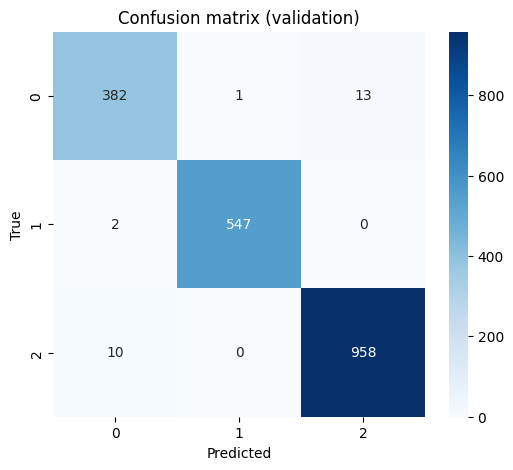

In [45]:
# TabKANet-style implementation (KAN for numerics + Transformer) + training/eval cell
# Requires: torch, sklearn, numpy, pandas, seaborn, matplotlib
# Citations: TabKANet (TabKANet: Tabular Data Modelling with Kolmogorov-Arnold Network + Transformer)
# and KAN (Kolmogorov-Arnold Networks). See: :contentReference[oaicite:1]{index=1}

import numpy as np, pandas as pd, torch, math, copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold

# -------------------- 0. Inputs you must have in scope --------------------
# df: DataFrame of features (your X DataFrame). If your DataFrame is named X, change below.
# y_encoded: numpy array of integer labels (0..C-1). If you only have y, encode beforehand.
# If your variable names differ, set `df = X.copy()` and `y_all = y_encoded` accordingly.

# Example: if you named your features DataFrame X (as in earlier cells), run:
try:
    df  # check
except NameError:
    df = X.copy()
try:
    y_all = np.asarray(y_encoded)
except NameError:
    # try y
    y_all = np.asarray(y)

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
indices = np.arange(len(y))
overlap_any = False

for fold, (train_idx, val_idx) in enumerate(skf.split(indices, y)):
    inter = np.intersect1d(train_idx, val_idx)
    print(f"Fold {fold} overlap train/val size:", len(inter))
    if len(inter) > 0:
        overlap_any = True

print("Any fold with overlap?", overlap_any)
# -------------------- 1. Defensive preprocessing --------------------
n_rows = len(df)
# detect numeric / categorical
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object","bool","category"]).columns.tolist()

# drop ID-like categorical columns (unique ratio > 0.5)
id_like = [c for c in cat_cols if df[c].nunique() / n_rows > 0.5]
if id_like:
    print("Dropping id-like categorical cols:", id_like)
    df = df.drop(columns=id_like)
    cat_cols = [c for c in cat_cols if c not in id_like]

# freq-encode very-high-card categorical cols (>1000 uniques)
freq_enc_cols = [c for c in cat_cols if df[c].nunique() > 1000]
for c in freq_enc_cols:
    vc = df[c].fillna("__MISSING__").astype(str).value_counts(normalize=True)
    df[c + "_freqenc"] = df[c].fillna("__MISSING__").astype(str).map(vc).fillna(0.0)
if freq_enc_cols:
    print("Freq-encoded:", freq_enc_cols)
    df = df.drop(columns=freq_enc_cols)
    # recompute cols lists
    num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object","bool","category"]).columns.tolist()

print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))

# Clip numeric extremes (1st-99th percentiles), fill inf/nan, scale
if len(num_cols) > 0:
    X_num = df[num_cols].astype(float).copy()
    # clip
    p1 = X_num.quantile(0.01)
    p99 = X_num.quantile(0.99)
    X_num = X_num.clip(lower=p1, upper=p99, axis=1)
    X_num.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_num = X_num.fillna(X_num.median())
    # robust then standard
    rsc = RobustScaler()
    ssc = StandardScaler()
    X_num_scaled = rsc.fit_transform(X_num)
    X_num_scaled = ssc.fit_transform(X_num_scaled).astype(np.float32)
else:
    X_num_scaled = np.zeros((n_rows, 0), dtype=np.float32)
#print(cat_cols)
# Categorical ordinal encoding and produce integer arrays
if len(cat_cols) > 0:
    X_cat_raw = df[cat_cols].drop(columns="koi_disposition").fillna("__MISSING__").astype(str).to_numpy()
    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_cat_enc = ord_enc.fit_transform(X_cat_raw).astype(int)
    # map unknown (-1) to padding index per column, and compute num_embeddings
    cat_card = []
    for i in range(X_cat_enc.shape[1]):
        col = X_cat_enc[:, i]
        padding_idx = int(col.max()) + 1
        col = np.where(col < 0, padding_idx, col)
        X_cat_enc[:, i] = col
        num_emb = int(X_cat_enc[:, i].max()) + 1
        cat_card.append(num_emb)
    X_cat_enc = X_cat_enc.astype(np.int64)
else:
    X_cat_enc = np.zeros((n_rows, 0), dtype=np.int64)
    cat_card = []

print("Prepared numeric shape:", X_num_scaled.shape, "cat shape:", X_cat_enc.shape)

# Train/val split (stratified)
Xn_train, Xn_val, Xc_train, Xc_val, y_tr, y_val = train_test_split(
    X_num_scaled, X_cat_enc, y_all, test_size=0.2, random_state=42, stratify=y_all)

# -------------------- 2. KAN module (vectorized) --------------------
class KANLayer(nn.Module):
    """
    Vectorized KAN-style module:
    - Inputs: x (B, n_inputs)
    - Internal "inner" linear combinations: u_q = x @ W[:, q] + b[q]  (q=0..K-1)
    - Apply per-q outer univariate mapping phi_q (shared small MLP applied vectorized)
    - Learnable mixing matrix A (K x n_out_features) to produce per-output-feature embeddings.
    - Output: (B, n_out, d_model) where n_out typically = n_inputs (one embedding per numeric feature)
    """
    def __init__(self, n_inputs, n_out, K_inner=16, d_model=64, phi_hidden=64):
        super().__init__()
        self.n_inputs = n_inputs
        self.n_out = n_out
        self.K = K_inner
        self.d_model = d_model
        # inner linear weights W: shape (n_inputs, K)
        self.W = nn.Parameter(torch.randn(n_inputs, K_inner) * (1.0 / math.sqrt(n_inputs)))
        self.b = nn.Parameter(torch.zeros(K_inner))
        # phi: small MLP applied to scalar u_q -> vector d_model, vectorized below
        self.phi = nn.Sequential(
            nn.Linear(1, phi_hidden),
            nn.GELU(),
            nn.Linear(phi_hidden, d_model)
        )
        # mixing matrix A: (K, n_out) -> how each inner channel contributes to each output feature
        self.A = nn.Parameter(torch.randn(K_inner, n_out) * (1.0 / math.sqrt(K_inner)))
        # optional layernorm on output vector dims
        self.ln = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, n_inputs)
        B = x.shape[0]
        device = x.device
        # compute u = x @ W + b -> (B, K)
        u = x @ self.W.to(device) + self.b.to(device)  # (B, K)
        # apply phi to each scalar of u vectorized:
        u_flat = u.reshape(-1, 1)                      # (B*K, 1)
        phi_out = self.phi(u_flat)                     # (B*K, d_model)
        phi_out = phi_out.view(B, self.K, self.d_model) # (B, K, d_model)
        # mix into per-output-feature embeddings using A: (K, n_out)
        # out = einsum 'bkd,kp->bpd' -> (B, n_out, d_model)
        out = torch.einsum('bkd,kp->bpd', phi_out, self.A.to(device))
        out = self.ln(out)
        return out  # (B, n_out, d_model)

# -------------------- 3. TabKANet-ish model --------------------
class TabKANet(nn.Module):
    def __init__(self, n_num, n_cat, cat_card_list, d_model=64, K_inner=16, trans_heads=4, trans_depth=3, mlp_hidden=128, n_classes=3, dropout=0.1):
        super().__init__()
        self.n_num = n_num
        self.n_cat = n_cat
        self.d_model = d_model
        # KAN: map numeric features -> (B, n_num, d_model)
        # Here set n_out = n_num so we output per-numeric-feature embedding
        self.kan = KANLayer(n_inputs=n_num if n_num>0 else 1, n_out=n_num if n_num>0 else 1, K_inner=K_inner, d_model=d_model, phi_hidden=max(32,d_model))
        # categorical embeddings
        self.cat_embs = nn.ModuleList([nn.Embedding(card, d_model, padding_idx=card-1) for card in cat_card_list]) if n_cat>0 else nn.ModuleList()
        # learned feature positional embedding for all features (num + cat)
        self.n_features = (n_num if n_num>0 else 0) + n_cat
        self.feat_emb = nn.Embedding(self.n_features + 1, d_model)
        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1,1,d_model) * 0.02)
        # transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model, trans_heads, dim_feedforward=mlp_hidden, dropout=dropout, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=trans_depth)
        self.head_ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

    def forward(self, x_num, x_cat):
        device = x_num.device if x_num is not None and x_num.numel() else next(self.parameters()).device
        # numeric KAN tokens (B, n_num, d_model)
        if self.n_num > 0:
            kan_out = self.kan(x_num)  # (B, n_num, d_model)
        else:
            kan_out = torch.zeros(x_cat.shape[0], 0, self.d_model, device=device)

        # categorical embeddings -> (B, n_cat, d_model)
        if self.n_cat > 0:
            cat_tokens = []
            for i, emb in enumerate(self.cat_embs):
                idxs = x_cat[:, i]
                pad = emb.padding_idx
                pad_t = torch.tensor(pad, dtype=idxs.dtype, device=device)
                idxs = torch.where(idxs < 0, pad_t, idxs).to(device)
                cat_tokens.append(emb(idxs))
            cat_tokens = torch.stack(cat_tokens, dim=1)  # (B, n_cat, d_model)
        else:
            cat_tokens = torch.zeros(x_num.shape[0], 0, self.d_model, device=device)

        # concatenate tokens per-feature in fixed order: numerics first, then cat
        tokens = torch.cat([kan_out, cat_tokens], dim=1)  # (B, n_features, d_model)
        B = tokens.shape[0]
        # add learned feature embeddings
        feat_idx = torch.arange(tokens.size(1), device=device).unsqueeze(0)  # (1, n_features)
        tokens = tokens + self.feat_emb(feat_idx)

        # prepend CLS
        cls = self.cls_token.expand(B, -1, -1)
        seq = torch.cat([cls, tokens], dim=1)   # (B, n_features+1, d_model)
        seq = seq.permute(1,0,2)                # (seq_len, B, d_model)
        out = self.transformer(seq)             # (seq_len, B, d_model)
        cls_out = out[0]                        # (B, d_model)
        logits = self.head(self.head_ln(cls_out))
        return logits

# -------------------- 4. Dataloader --------------------
class TabDataset(Dataset):
    def __init__(self, Xn, Xc, y):
        self.Xn = torch.tensor(Xn, dtype=torch.float32)
        self.Xc = torch.tensor(Xc, dtype=torch.long) if Xc.size else torch.zeros((len(Xn),0), dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.Xn[idx], self.Xc[idx], self.y[idx]

train_ds = TabDataset(Xn_train, Xc_train, y_tr)
val_ds   = TabDataset(Xn_val,   Xc_val,   y_val)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)

# -------------------- 5. Instantiate model + training objects --------------------
n_num = Xn_train.shape[1]
n_cat = Xc_train.shape[1]
n_classes = len(np.unique(y_all))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TabKANet(n_num=n_num, n_cat=n_cat, cat_card_list=cat_card, d_model=64, K_inner=min(32, max(8, n_num*2)), trans_heads=4, trans_depth=3, mlp_hidden=256, n_classes=n_classes, dropout=0.12)
model = model.to(device)
print("Model params:", sum(p.numel() for p in model.parameters()))

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
crit = nn.CrossEntropyLoss(label_smoothing=0.03)
# optional scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3, verbose=True)

# -------------------- 6. Training loop with early stopping --------------------
best_f1 = -1.0
best_state = None
patience = 6
no_improve = 0
epochs = 40
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    seen = 0
    for xb_num, xb_cat, yb in train_loader:
        xb_num = xb_num.to(device)
        xb_cat = xb_cat.to(device)
        yb = yb.to(device)
        opt.zero_grad()
        logits = model(xb_num, xb_cat)
        loss = crit(logits, yb)
        if not torch.isfinite(loss):
            print("Skipping non-finite loss batch")
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        running_loss += float(loss.item()) * len(yb)
        seen += len(yb)
    train_loss = running_loss / max(1, seen)

    # evaluate
    model.eval()
    preds_all = []
    trues_all = []
    with torch.no_grad():
        for xb_num, xb_cat, yb in val_loader:
            xb_num = xb_num.to(device)
            xb_cat = xb_cat.to(device)
            logits = model(xb_num, xb_cat)
            preds = logits.argmax(dim=1).cpu().numpy()
            preds_all.append(preds)
            trues_all.append(yb.numpy())
    preds_all = np.concatenate(preds_all)
    trues_all = np.concatenate(trues_all)
    val_f1 = f1_score(trues_all, preds_all, average='weighted')

    print(f"Epoch {epoch:02d} train_loss={train_loss:.6f} val_f1={val_f1:.4f}")
    scheduler.step(val_f1)

    if val_f1 > best_f1 + 1e-6:
        best_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
        print("  -> new best")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"No improvement for {patience} epochs — early stopping.")
            break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)

# -------------------- 7. Final metrics - weighted F1 + confusion matrix --------------------
model.eval()
preds_all = []
trues_all = []
probs_all = []
with torch.no_grad():
    for xb_num, xb_cat, yb in val_loader:
        xb_num = xb_num.to(device)
        xb_cat = xb_cat.to(device)
        logits = model(xb_num, xb_cat)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        preds_all.append(preds)
        trues_all.append(yb.numpy())
        probs_all.append(probs)

preds_all = np.concatenate(preds_all)
trues_all = np.concatenate(trues_all)
probs_all = np.vstack(probs_all)

print("Validation weighted F1:", f1_score(trues_all, preds_all, average='weighted'))
print("Classification report:\n", classification_report(trues_all, preds_all, digits=4))

cm = confusion_matrix(trues_all, preds_all)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix (validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# 7 — Compare multiple models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "LGB": LGBMClassifier(metric="multi_logloss", random_state=42,verbose=-1),
    "CB": CatBoostClassifier(eval_metric="MultiClass", verbose=0, random_state=42),
}

In [ ]:
results = {}
for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds, average="weighted")
    }
pd.DataFrame(results).T

# 8 — Hyperparameter tuning (RandomForest example)

In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier
from sklearn.pipeline import make_pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import shap
import joblib

# Define parameter grid for LGBM
param_grid = {
    "lgbmclassifier__n_estimators": [100, 200, 500],
    "lgbmclassifier__max_depth": [-1, 10, 20],  # -1 means no limit in LightGBM
    "lgbmclassifier__num_leaves": [31, 63, 127],
}

# Build pipeline with LGBM
lgbm_pipe = make_pipeline(preprocessor, LGBMClassifier(metric="multi_logloss", random_state=42,verbose=-1))

# GridSearchCV
grid = GridSearchCV(lgbm_pipe, param_grid, cv=3, scoring="f1_weighted", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

# 9 — Evaluate best model

In [ ]:
# Best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Classification results
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 10 — Feature importance (interpretability)

In [ ]:
import numpy as np
import pandas as pd
import shap

# 0) Prepare transformed data (use transform NOT fit_transform)
X_tr = preprocessor.transform(X_train)[:200]

# If sparse -> convert to dense
if hasattr(X_tr, "toarray"):
    X_tr = X_tr.toarray()
X_tr = np.asarray(X_tr)
n_features = X_tr.shape[1]

# 1) Try to obtain correct transformed feature names
feature_names = None
try:
    # sklearn >=1.0 ColumnTransformer and Pipelines support this
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    try:
        # Some versions require passing the input feature names
        feature_names = preprocessor.get_feature_names_out(X_train.columns)
    except Exception:
        # Fall back to trying to extract names from ColumnTransformer internals
        if hasattr(preprocessor, "transformers_"):
            names = []
            for name, trans, cols in preprocessor.transformers_:
                # skip 'remainder'== 'drop'
                if name == "remainder" and trans == "drop":
                    continue
                # If transformer itself can produce feature names:
                if hasattr(trans, "get_feature_names_out"):
                    try:
                        out = trans.get_feature_names_out(cols)
                    except Exception:
                        # If transformer is a pipeline, try its last step
                        if hasattr(trans, "named_steps"):
                            last = list(trans.named_steps.values())[-1]
                            out = getattr(last, "get_feature_names_out", lambda c: [str(x) for x in c])(cols)
                        else:
                            out = [str(c) for c in cols]
                    # ensure iterable
                    names.extend(list(out))
                else:
                    # no name generator -> keep original column names for that block
                    names.extend([str(c) for c in cols])
            feature_names = np.array(names)
        else:
            # Ultimate fallback: generic feature names
            feature_names = np.array([f"f{i}" for i in range(n_features)])

# 2) Ensure lengths match; otherwise replace with generic names
if len(feature_names) != n_features:
    print(f"Warning: feature_names length ({len(feature_names)}) != transformed feature count ({n_features}). "
          "Using generated names to match shape.")
    feature_names = [f"f{i}" for i in range(n_features)]
else:
    feature_names = list(feature_names)

# 3) Make a DataFrame for nicer plotting labels (optional but helps)
X_tr_df = pd.DataFrame(X_tr, columns=feature_names)

# 4) Obtain SHAP values robustly (try shap.Explainer first, then TreeExplainer on booster)
shap_vals_array = None
try:
    explainer = shap.Explainer(best_model.named_steps["lgbmclassifier"], feature_names=feature_names)
    sh_exp = explainer(X_tr)               # shap.Explanation
    shap_vals_array = np.asarray(sh_exp.values)   # could be 2D or 3D
except Exception as e:
    print("shap.Explainer failed, falling back to TreeExplainer on booster_. Error:", e)
    booster = getattr(best_model.named_steps["lgbmclassifier"], "booster_", best_model.named_steps["lgbmclassifier"])
    explainer = shap.TreeExplainer(booster)
    raw = explainer.shap_values(X_tr)      # may be list-of-arrays or array
    if isinstance(raw, list):
        try:
            shap_vals_array = np.stack(raw, axis=-1)  # (n_samples, n_features, n_classes)
        except Exception:
            # last-resort: convert to ndarray (may produce ragged array if shapes inconsistent)
            shap_vals_array = np.asarray(raw)
    else:
        shap_vals_array = np.asarray(raw)

# 5) Final safety check
if shap_vals_array is None:
    raise RuntimeError("Failed to compute SHAP values with both Explainer and TreeExplainer fallback.")

shap_vals_array = np.asarray(shap_vals_array)

# 6) Plotting: handle single-output (2D) or multiclass (3D)
if shap_vals_array.ndim == 3:
    # (n_samples, n_features, n_classes)
    n_classes = shap_vals_array.shape[2]
    for class_idx in range(n_classes):
        print(f"\nSHAP summary plot for class {class_idx}")
        shap.summary_plot(
            shap_vals_array[:, :, class_idx],
            X_tr_df,
            feature_names=feature_names,
            show=True
        )
elif shap_vals_array.ndim == 2:
    # (n_samples, n_features) single output
    shap.summary_plot(
        shap_vals_array,
        X_tr_df,
        feature_names=feature_names,
        show=True
    )
else:
    raise ValueError(f"Unexpected shap_vals_array shape: {shap_vals_array.shape}")

# 11 - Adversarial Machine Learning

In [ ]:
%pip install adversarial-robustness-toolbox==1.*

In [ ]:
# Robust ART wrapper + HopSkipJump attack (fixes clip_values min >= max problem)
import numpy as np
from scipy import sparse
import inspect
from lightgbm import LGBMClassifier

# --- helper: convert preprocessor output to dense float (subset-friendly) ---
def preproc_to_dense_float(X_proc):
    if sparse.issparse(X_proc):
        return X_proc.toarray().astype(float, copy=False)
    if hasattr(X_proc, "to_numpy") and not sparse.issparse(X_proc):
        return X_proc.to_numpy().astype(float, copy=False)
    if isinstance(X_proc, np.ndarray):
        if X_proc.dtype == object:
            flattened = X_proc.flatten()
            if len(flattened) == 0:
                return np.empty((0, 0), dtype=float)
            if all(sparse.issparse(el) for el in flattened):
                stacked = sparse.hstack(flattened)
                return stacked.toarray().astype(float, copy=False)
            return X_proc.astype(float)
        return X_proc.astype(float, copy=False)
    return np.asarray(X_proc, dtype=float)

# --- prepare preprocessed arrays (attack a subset to save memory) ---
X_train_proc_raw = preprocessor.transform(X_train)
n_attack = min(200, len(X_test))
X_test_subset_raw = preprocessor.transform(X_test.iloc[:n_attack] if hasattr(X_test, "iloc") else X_test[:n_attack])

X_train_proc = preproc_to_dense_float(X_train_proc_raw)
X_test_subset = preproc_to_dense_float(X_test_subset_raw)

# --- compute clip_values robustly ---
# use nan-aware min/max and ensure finite values
x_min = np.nanmin(X_train_proc, axis=0).astype(float)
x_max = np.nanmax(X_train_proc, axis=0).astype(float)

# replace non-finite with zeros and warn
bad_mask = ~np.isfinite(x_min) | ~np.isfinite(x_max)
if bad_mask.any():
    print(f"Warning: {bad_mask.sum()} feature(s) had non-finite min/max; replacing with 0/1 defaults.")
    x_min[~np.isfinite(x_min)] = 0.0
    x_max[~np.isfinite(x_max)] = 1.0

# if some features are constant or min >= max, expand by small epsilon
eq_mask = x_min >= x_max
if eq_mask.any():
    print(f"Warning: {eq_mask.sum()} constant or invalid feature(s) detected. Expanding by epsilon to make clip_values valid.")
    # use a relative epsilon where possible
    eps = 1e-6
    rel_eps = 1e-3 * np.maximum(np.abs(x_min), 1.0)  # fallback scale
    delta = np.maximum(eps, rel_eps)
    # only apply delta for eq_mask features
    x_min[eq_mask] = x_min[eq_mask] - delta[eq_mask]
    x_max[eq_mask] = x_max[eq_mask] + delta[eq_mask]

# final sanity check
if np.any(x_min >= x_max):
    raise ValueError("clip_values still invalid after repair: some min >= max. Inspect X_train_proc for NaNs or constant columns.")

clip_values = (x_min, x_max)
n_features = X_train_proc.shape[1]
nb_classes = len(np.unique(y_train))

# --- train (or use existing) LightGBM sklearn wrapper on preprocessed features ---
# If you already have a trained sklearn LGB object, replace the next lines with it.
lgb_sklearn = LGBMClassifier(metric="multi_logloss", random_state=42, verbose=-1)
lgb_sklearn.fit(X_train_proc, y_train)

# --- Try ART LightGBM wrapper (expects a lightgbm.Booster) ---
clf_art = None
try:
    # ART wrapper import (varies by ART version)
    try:
        from art.estimators.classification.lightgbm import LightGBMClassifier as ARTLightGBM
    except Exception:
        from art.estimators.classification import LightGBMClassifier as ARTLightGBM

    booster_obj = getattr(lgb_sklearn, "booster_", None)
    if booster_obj is None:
        # If no booster_ available (should normally be present), try to get from LGB API
        booster_obj = lgb_sklearn.booster()
    # Try constructing wrapper; some ART versions accept different kwargs
    try:
        clf_art = ARTLightGBM(model=booster_obj, clip_values=clip_values)
    except TypeError:
        # some versions might want 'model' name different or require nb_classes
        try:
            clf_art = ARTLightGBM(booster_obj, clip_values=clip_values)
        except Exception:
            clf_art = ARTLightGBM(model=booster_obj, clip_values=clip_values, nb_classes=nb_classes)
    print("ART LightGBM wrapper created (using Booster).")
except Exception as e_light:
    print("ART LightGBM wrapper failed; falling back to BlackBox. Error:", e_light)

# --- Fallback: robust BlackBox wrapper construction using inspect to adapt to API variations ---
if clf_art is None:
    try:
        from art.estimators.classification import BlackBoxClassifier
    except Exception:
        # alternative import paths in older ART versions
        from art.estimators.classification.blackbox import BlackBoxClassifier

    # choose predict function that returns probabilities (shape (n_samples, nb_classes))
    def predict_fn_probs(x_batch: np.ndarray):
        probs = lgb_sklearn.predict_proba(x_batch)
        # ensure shape (n_samples, nb_classes)
        if probs.ndim == 1:
            # binary single-prob output -> convert to two-column probs
            probs = np.vstack([1 - probs, probs]).T
        return probs

    # inspect constructor signature and adapt arg names
    ctor = BlackBoxClassifier
    sig = inspect.signature(ctor.__init__)
    kwargs = {}
    # possible names for predict_fn param
    for pname in ("predict_fn", "predict_function", "predict"):
        if pname in sig.parameters:
            kwargs[pname] = predict_fn_probs
            break
    if "input_shape" in sig.parameters:
        kwargs["input_shape"] = (n_features,)
    if "nb_classes" in sig.parameters:
        kwargs["nb_classes"] = nb_classes
    if "clip_values" in sig.parameters:
        kwargs["clip_values"] = clip_values

    # try to construct, raising an informative error if it fails
    try:
        clf_art = ctor(**kwargs)
        print("BlackBoxClassifier created with kwargs:", list(kwargs.keys()))
    except TypeError as e_bb:
        # last resort: try a minimal set
        print("BlackBoxClassifier construction failed with kwargs:", kwargs, "Error:", e_bb)
        # try without nb_classes if present
        kwargs2 = {k: v for k, v in kwargs.items() if k != "nb_classes"}
        clf_art = ctor(**kwargs2)
        print("BlackBoxClassifier created with fallback kwargs:", list(kwargs2.keys()))

# --- instantiate HopSkipJump attacking the wrapped classifier (tolerant to param name differences) ---
from art.attacks.evasion import HopSkipJump

try:
    attack = HopSkipJump(classifier=clf_art, max_iter=20, max_eval=1000, init_eval=10)
except TypeError:
    attack = HopSkipJump(estimator=clf_art, max_iter=20, max_eval=1000, init_eval=10)

# generate adversarials for X_test_subset
try:
    x_adv = attack.generate(x=X_test_subset)
except TypeError:
    x_adv = attack.generate(X_test_subset)

def sanitize_adv(x_adv, x_min, x_max, x_orig=None, replace_nan_with="clip"):
    """
    1) Replace NaN/Inf in x_adv.
    2) Clip to clip_values (x_min/x_max).
    3) Optionally, if replace_nan_with='orig' and x_orig provided, replace NaNs by original sample.
    Returns sanitized array and a dict of counts.
    """
    x = x_adv.copy()
    counts = {"nan_total": np.isnan(x).sum(), "inf_total": np.isinf(x).sum()}
    # If NaNs/Inf and original provided, replace elementwise with original
    if (counts["nan_total"] > 0 or counts["inf_total"] > 0) and (replace_nan_with == "orig" and x_orig is not None):
        # x_orig expected to have same shape
        mask_bad = ~np.isfinite(x)
        x[mask_bad] = x_orig[mask_bad]
        counts["replaced_with_orig"] = mask_bad.sum()
    else:
        # replace NaN with clip midpoints, Inf with clip extremes
        nan_mask = np.isnan(x)
        if nan_mask.any():
            mid = (x_min + x_max) / 2.0
            # broadcast mid: shape (n_features,)
            x[nan_mask] = np.take(mid, np.where(nan_mask)[1])
            counts["replaced_nan_with_mid"] = nan_mask.sum()
        inf_mask = np.isinf(x)
        if inf_mask.any():
            # replace +inf with x_max, -inf with x_min
            pos_inf = (x == np.PINF)
            neg_inf = (x == np.NINF)
            x[pos_inf] = np.take(x_max, np.where(pos_inf)[1])
            x[neg_inf] = np.take(x_min, np.where(neg_inf)[1])
            counts["replaced_inf_with_bounds"] = inf_mask.sum()

    # Now clip strictly to clip_values
    x = np.minimum(np.maximum(x, x_min), x_max)
    return x, counts

def perturbation_stats(x_clean, x_adv):
    """
    Compute per-sample L0, L2, Linf and return summary dict.
    """
    delta = x_adv - x_clean
    l0 = np.sum(np.abs(delta) > 1e-12, axis=1)
    l2 = np.linalg.norm(delta, axis=1)
    linf = np.max(np.abs(delta), axis=1)
    return {
        "L0_mean": l0.mean(), "L0_median": np.median(l0), "L0_max": l0.max(),
        "L2_mean": l2.mean(), "L2_median": np.median(l2), "L2_max": l2.max(),
        "Linf_mean": linf.mean(), "Linf_median": np.median(linf), "Linf_max": linf.max(),
        "count": len(l0)
    }

def detect_onehot_groups(X_ref, threshold_unique_values=10, onehot_sum_tol=1e-2):
    """
    Heuristic detection of contiguous one-hot groups.
    - Looks for column groups where values are mostly 0/1 in X_ref and per-row sum ~1.
    - Returns a list of (start_idx, end_idx) index ranges (inclusive start, exclusive end).
    NOTE: this is heuristic; inspect and override manually if needed.
    """
    X = np.asarray(X_ref)
    n_samples, n_feats = X.shape
    is_01 = np.logical_or(np.isclose(X, 0.), np.isclose(X, 1.))
    # fraction of entries that are 0/1 per column
    frac01 = is_01.sum(axis=0) / n_samples
    candidate_cols = np.where(frac01 > 0.95)[0]  # mostly binary columns
    groups = []
    if len(candidate_cols) == 0:
        return groups
    # cluster contiguous candidate columns into groups
    current_group = [candidate_cols[0]]
    for col in candidate_cols[1:]:
        if col == current_group[-1] + 1:
            current_group.append(col)
        else:
            groups.append((current_group[0], current_group[-1]+1))
            current_group = [col]
    groups.append((current_group[0], current_group[-1]+1))
    # filter groups by checking per-row sums ~1
    filtered = []
    for s,e in groups:
        block = X[:, s:e]
        row_sums = np.sum(block, axis=1)
        frac_close_to_1 = np.mean(np.isclose(row_sums, 1.0, atol=onehot_sum_tol))
        # also limit groups to small number of unique column-values (one-hot typically has few columns)
        if frac_close_to_1 > 0.8 and (e-s) <= threshold_unique_values:
            filtered.append((s,e))
    return filtered

def snap_onehot(x_adv, groups):
    """
    For each group (s,e), make each row choose argmax within group and set that index to 1, others 0.
    """
    x = x_adv.copy()
    for s,e in groups:
        block = x[:, s:e]
        idx = np.argmax(block, axis=1)
        # zero out block
        x[:, s:e] = 0.0
        rows = np.arange(x.shape[0])
        x[rows, s + idx] = 1.0
    return x

# --- Perform sanitation, snapping, and evaluation ---
# x_adv: produced by your attack; X_test_subset: clean preprocessed inputs; y_test subset
x_orig = X_test_subset.copy()
x_adv_raw = x_adv.copy()  # from attack

# 1) sanitize NaNs/Infs & clip
x_adv_cleaned, counts = sanitize_adv(x_adv_raw, x_min, x_max, x_orig=x_orig, replace_nan_with="clip")
print("Sanitization counts:", counts)

# 2) detect one-hot groups heuristically from training preprocessed data (X_train_proc)
oh_groups = detect_onehot_groups(X_train_proc)
print("Detected one-hot groups (start,end):", oh_groups)

# 3) snap one-hot groups back to valid if any detected
if len(oh_groups) > 0:
    x_adv_snapped = snap_onehot(x_adv_cleaned, oh_groups)
else:
    x_adv_snapped = x_adv_cleaned

# 4) final clip after snapping (safety)
x_adv_snapped = np.minimum(np.maximum(x_adv_snapped, x_min), x_max)

# 5) compute perturbation stats (comparing to original preprocessed inputs)
stats = perturbation_stats(x_orig, x_adv_snapped)
print("Perturbation stats:", stats)

# 6) predictions and metrics
orig_preds = np.argmax(lgb_sklearn.predict_proba(x_orig), axis=1)
adv_preds  = np.argmax(lgb_sklearn.predict_proba(x_adv_snapped), axis=1)

print("Original acc on subset:", accuracy_score(y_test[:len(orig_preds)], orig_preds))
print("After attack acc on subset (sanitized & snapped):", accuracy_score(y_test[:len(orig_preds)], adv_preds))
print("Original F1:", f1_score(y_test[:len(orig_preds)], orig_preds, average='weighted'))
print("After attack F1:", f1_score(y_test[:len(orig_preds)], adv_preds, average='weighted'))

# 7) confusion matrix
cm_before = confusion_matrix(y_test[:len(orig_preds)], orig_preds)
cm_after  = confusion_matrix(y_test[:len(orig_preds)], adv_preds)
print("Confusion matrix BEFORE:\n", cm_before)
print("Confusion matrix AFTER:\n", cm_after)

# 8) warn about any remaining NaN/Inf
if not np.all(np.isfinite(x_adv_snapped)):
    warnings.warn("Some adversarial values are still non-finite after sanitation.")

# 12 — Save final model

In [ ]:
import joblib
joblib.dump(
    {"pipeline": best_model, "label_encoder": le2, "features": X.columns.tolist()},
    "exoplanet_model.joblib"
)
print("Model saved as exoplanet_model.joblib")